
# Mercado Libre Item Condition EDA

Initial exploratory analysis of the `MLA_100k.jsonlines` dataset to understand feature distribution and quality ahead of building a condition (new vs used) classifier.



## Objectives
- Inspect dataset structure, types, and target balance
- Quantify missingness and identify high-signal features
- Explore numeric fields such as `price`, `base_price`, `sold_quantity`
- Profile categorical/textual fields (e.g., `category_id`, `listing_type_id`, `title`)


In [2]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')


In [9]:

DATA_PATH = Path('MLA_100k.jsonlines')
assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH.resolve()}"

df_raw = pd.read_json(DATA_PATH, lines=True)
print(f"Loaded {len(df_raw):,} records with {df_raw.shape[1]} columns")
df_raw.head(5)


Loaded 100,000 records with 48 columns


,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity
0,"{'comment': '', 'longitude': -58.3986709, 'id': 78162842, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_lin...",None,[],new,None,[],80.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'not_specified', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Acordar con el comprador', ...",74952096,[],{},MLA,bronze,80.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568261029,[],MLA126406,[{'id': 'MLA578052519-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-O.jpg'...",MLA578052519,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-I.jpg,Auriculares Samsung Originales Manos Libres Cable Usb Oferta,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-I.jpg,2015-11-04 20:42:53+00:00,active,None,NaN,NaN,1,2015-09-05 20:42:53+00:00,http://articulo.mercadolibre.com.ar/MLA-578052519-auriculares-samsung-originales-manos-libres-cable-usb-oferta-_JM,"{'latitude': -34.6280698, 'longitude': -58.3986709}",0,1
1,"{'comment': '', 'longitude': -58.5059173, 'id': 105272448, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_li...",NUESTRA REPUTACION,[],used,None,[],2650.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Efectivo', 'id': 'MLAMO', '...",42093335,[],{},MLA,silver,2650.0,[],buy_it_now,[],,MLA561574487,[],MLA10267,[{'id': 'MLA581565358-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-O.jp...",MLA581565358,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-I.jpg,Cuchillo Daga Acero Carbón Casco Yelmo Solingen Con Vaina,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-I.jpg,2015-11-25 18:08:30+00:00,active,None,NaN,NaN,1,2015-09-26 18:08:30+00:00,http://articulo.mercadolibre.com.ar/MLA-581565358-cuchillo-daga-acero-carbon-casco-yelmo-solingen-con-vaina-_JM,"{'latitude': -34.5935524, 'longitude': -58.5059173}",0,1
2,"{'comment': '', 'longitude': -58.4143948, 'id': 103489016, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_li...",None,[],used,None,[],60.0,"{'local_pick_up': True, 'methods': [], 'tags': [], 'free_shipping': False, 'mode': 'me2', 'dimensions': None}","[{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}, {'description': 'Tarjeta de crédito', 'id': ...",133384258,[],{},MLA,bronze,60.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568881256,[],MLA1227,[{'id': 'MLA578780872-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a248.e.akamai.net/mla-s1-p.mlstatic.com/22076-MLA20223367605_012015-O.jp...",MLA578780872,NaN,NaN,True,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367605_012015-I.jpg,"Antigua Revista Billiken, N° 1826, Año 1954",False,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/22076-MLA20223367605_012015-I.jpg,2015-11-08 23:57:07+00:00,active,None,NaN,NaN,1,2015-09-09 23:57:07+00:00,http://articulo

## Target Condition Insights
- Slight class imbalance: `new` items account for 53.76% (53,758) of listings versus 46.24% (46,242) `used` items.
- Accuracy will probably remain meaningful because both classes are well represented; no single label dominates.
- Near-balanced classes suggest we can use stratified sampling for train/test splits to preserve distribution.

In [4]:

condition_counts = df_raw['condition'].value_counts(dropna=False)
condition_ratio = df_raw['condition'].value_counts(normalize=True, dropna=False)

target_summary = pd.DataFrame({
    'count': condition_counts,
    'ratio': condition_ratio
})

target_summary


,count,ratio
condition,,
new,53758,0.53758
used,46242,0.46242


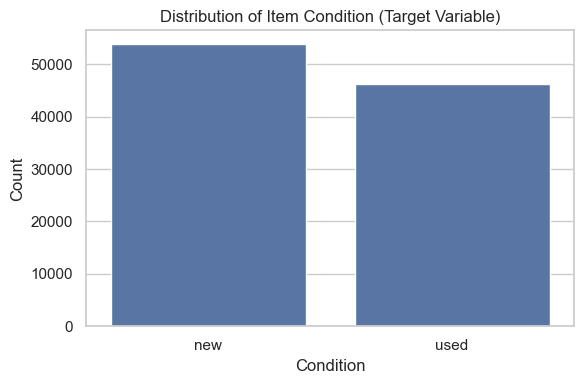

In [8]:
# Target distribution for 'condition'
plt.figure(figsize=(6, 4))
sns.countplot(x='condition', data=df_raw)
plt.title('Distribution of Item Condition (Target Variable)')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation matrix for numeric features
numeric_cols = df_raw.select_dtypes(include=['float64', 'int64']).copy()
numeric_cols['condition'] = df_raw['condition'].map({'new': 1, 'used': 0})

In [5]:

dtype_info = (
    df_raw.dtypes
    .astype(str)
    .reset_index()
    .rename(columns={'index': 'feature', 0: 'dtype'})
)

dtype_info.head(20)


,feature,dtype
0,seller_address,object
1,warranty,object
2,sub_status,object
3,condition,object
4,seller_contact,object
5,deal_ids,object
6,base_price,float64
7,shipping,object
8,non_mercado_pago_payment_methods,object
9,seller_id,int64


## Nested Feature Breakdown
- Detect columns containing dictionaries or lists to understand hierarchical data
- Flatten dictionary-based fields into analyzable columns
- Explode list-based fields to inspect their element-level structure

In [10]:
from collections import Counter
from itertools import chain

nested_meta = []
for col in df_raw.columns:
    non_null = df_raw[col].dropna()
    if non_null.empty:
        continue
    first_nested = next((val for val in non_null if isinstance(val, (dict, list))), None)
    if first_nested is None:
        continue
    share_non_null = 1 - df_raw[col].isna().mean()
    if isinstance(first_nested, dict):
        key_counter = Counter(chain.from_iterable(v.keys() for v in non_null if isinstance(v, dict)))
        nested_meta.append({
            'column': col,
            'nested_type': 'dict',
            'non_null_ratio': share_non_null,
            'unique_keys': len(key_counter),
            'top_keys': ', '.join(list(key_counter)[:5])
        })
    elif isinstance(first_nested, list):
        lengths = [len(v) for v in non_null if isinstance(v, list)]
        element_counter = Counter()
        for v in non_null:
            if isinstance(v, list):
                element_counter.update(type(elem).__name__ for elem in v if elem is not None)
        nested_meta.append({
            'column': col,
            'nested_type': 'list',
            'non_null_ratio': share_non_null,
            'mean_length': float(pd.Series(lengths).mean()) if lengths else 0.0,
            'median_length': float(pd.Series(lengths).median()) if lengths else 0.0,
            'element_types': ', '.join(f"{k}:{v}" for k, v in element_counter.most_common(3))
        })
nested_summary = pd.DataFrame(nested_meta)
nested_summary.sort_values(['nested_type', 'column']).reset_index(drop=True)

,column,nested_type,non_null_ratio,unique_keys,top_keys,mean_length,median_length,element_types
0,geolocation,dict,1.00000,2.0,"latitude, longitude",NaN,NaN,NaN
1,location,dict,1.00000,9.0,"open_hours, neighborhood, longitude, country, address_line",NaN,NaN,NaN
2,seller_address,dict,1.00000,10.0,"comment, longitude, id, country, address_line",NaN,NaN,NaN
3,seller_contact,dict,0.02219,8.0,"area_code2, phone2, webpage, email, contact",NaN,NaN,NaN
4,shipping,dict,1.00000,7.0,"local_pick_up, methods, tags, free_shipping, mode",NaN,NaN,NaN
5,attributes,list,1.00000,NaN,NaN,1.18755,0.0,dict:118755
6,coverage_areas,list,1.00000,NaN,NaN,0.00000,0.0,
7,deal_ids,list,1.00000,NaN,NaN,0.00286,0.0,str:286
8,descriptions,list,1.00000,NaN,NaN,0.97312,1.0,dict:97312
9,non_mercado_pago_payment_methods,list,1.00000,NaN,NaN,1.58332,2.0,dict:158332


In [11]:
from IPython.display import display

dict_cols = [row['column'] for row in nested_meta if row['nested_type'] == 'dict']
if dict_cols:
    dict_flat = pd.json_normalize(df_raw.to_dict(orient='records'), sep='.')
    dict_flat = dict_flat[[c for c in dict_flat.columns if any(c.startswith(f'{col}.') for col in dict_cols)]]
    dict_flat = dict_flat.rename(columns=lambda c: c.replace('.', '__'))
    print(f'Flattened dict-derived columns: {dict_flat.shape[1]}')
    display(dict_flat.head(3))
else:
    print('No dict-based columns detected.')

Flattened dict-derived columns: 48


,seller_address__comment,seller_address__longitude,seller_address__id,seller_address__country__name,seller_address__country__id,seller_address__address_line,seller_address__latitude,seller_address__search_location__neighborhood__name,seller_address__search_location__neighborhood__id,seller_address__search_location__state__name,seller_address__search_location__state__id,seller_address__search_location__city__name,seller_address__search_location__city__id,seller_address__zip_code,seller_address__city__name,seller_address__city__id,seller_address__state__name,seller_address__state__id,shipping__local_pick_up,shipping__methods,shipping__tags,shipping__free_shipping,shipping__mode,shipping__dimensions,geolocation__latitude,geolocation__longitude,shipping__free_methods,seller_contact__area_code2,seller_contact__phone2,seller_contact__webpage,seller_contact__email,seller_contact__contact,seller_contact__area_code,seller_contact__other_info,seller_contact__phone,location__open_hours,location__neighborhood__name,location__neighborhood__id,location__longitude,location__country__name,location__country__id,location__address_line,location__latitude,location__zip_code,location__city__name,location__city__id,location__state__name,location__state__id
0,,-58.398671,78162842,Argentina,AR,,-34.62807,San Cristóbal,TUxBQlNBTjkwNTZa,Capital Federal,TUxBUENBUGw3M2E1,Capital Federal,TUxBQ0NBUGZlZG1sYQ,,San Cristóbal,TUxBQlNBTjkwNTZa,Capital Federal,AR-C,True,[],[],False,not_specified,None,-34.62807,-58.398671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,-58.505917,105272448,Argentina,AR,,-34.593552,Villa Devoto,TUxBQlZJTDYzNzZa,Capital Federal,TUxBUENBUGw3M2E1,Capital Federal,TUxBQ0NBUGZlZG1sYQ,,Buenos Aires,,Capital Federal,AR-C,True,[],[],False,me2,None,-34.593552,-58.505917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,-58.414395,103489016,Argentina,AR,,-34.623391,Boedo,TUxBQkJPRTQ0OTRa,Capital Federal,TUxBUENBUGw3M2E1,Capital Federal,TUxBQ0NBUGZlZG1sYQ,,Boedo,TUxBQkJPRTQ0OTRa,Capital Federal,AR-C,True,[],[],False,me2,None,-34.623391,-58.414395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
from IPython.display import display

list_cols = [row['column'] for row in nested_meta if row['nested_type'] == 'list']
list_tables = {}
for col in list_cols:
    exploded = df_raw[['id', col]].explode(col).dropna(subset=[col])
    if exploded.empty:
        continue
    if exploded[col].apply(lambda x: isinstance(x, dict)).all():
        normalized = pd.json_normalize(exploded[col]).add_prefix(f'{col}__')
        table = pd.concat([exploded[['id']].reset_index(drop=True), normalized], axis=1)
    else:
        table = exploded.rename(columns={col: f'{col}__value'}).reset_index(drop=True)
    list_tables[col] = table
if list_tables:
    for col, table in list_tables.items():
        print(f'Column: {col} -> {table.shape[0]} rows, {table.shape[1]} columns')
        display(table.head(3))
else:
    print('No list-based columns detected.')

Column: sub_status -> 986 rows, 2 columns


,id,sub_status__value
0,MLA583761340,suspended
1,MLA578946385,suspended
2,MLA584453681,suspended


Column: deal_ids -> 286 rows, 2 columns


,id,deal_ids__value
0,MLA578140732,MLA60
1,MLA582017320,MLA25
2,MLA582649062,MLA70


Column: non_mercado_pago_payment_methods -> 158332 rows, 4 columns


...

,id,tags__value
0,MLA578052519,dragged_bids_and_visits
1,MLA578780872,dragged_bids_and_visits
2,MLA576112692,dragged_bids_and_visits


Column: descriptions -> 97312 rows, 2 columns


,id,descriptions__id
0,MLA578052519,MLA578052519-912855983
1,MLA581565358,MLA581565358-930764806
2,MLA578780872,MLA578780872-916478256


Column: pictures -> 293136 rows, 7 columns


,id,pictures__size,pictures__secure_url,pictures__max_size,pictures__url,pictures__quality,pictures__id
0,MLA578052519,500x375,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-O.jpg,1200x900,http://mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-O.jpg,,5386-MLA4352067878_052013
1,MLA578052519,500x375,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5361-MLA4352068035_052013-O.jpg,1200x900,http://mla-s1-p.mlstatic.com/5361-MLA4352068035_052013-O.jpg,,5361-MLA4352068035_052013
2,MLA581565358,499x334,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-O.jpg,951x637,http://mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-O.jpg,,23223-MLA20245018984_022015


## Final Feature Table
Creating a flattened, model-ready dataset that consolidates nested dictionaries and list attributes into engineered features aligned with the target label.

In [ ]:
df_features = build_feature_table(df_raw)
df_features.shape

In [26]:
df_features.head(5)

,warranty,condition,seller_contact,base_price,seller_id,site_id,listing_type_id,price,buying_mode,listing_source,parent_item_id,category_id,last_updated,international_delivery_mode,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,...,tags__contains_dragged_visits,tags__contains_free_relist,tags__contains_poor_quality_thumbnail,coverage_areas__len,coverage_areas__has_values,descriptions__len,descriptions__has_values,descriptions__has_key_id,pictures__len,pictures__has_values,pictures__has_key_size,pictures__has_key_secure_url,pictures__has_key_max_size,pictures__has_key_url,pictures__has_key_quality,shipping__methods__len,shipping__methods__has_values,shipping__tags__len,shipping__tags__has_values,shipping__tags__contains_relisted_with_modifications,shipping__tags__contains_free_method_upgraded,shipping__free_methods__len,shipping__free_methods__has_values,shipping__free_methods__has_key_rule,shipping__free_methods__has_key_id
0,<NA>,new,NaN,80.0,74952096,MLA,bronze,80.0,buy_it_now,,MLA568261029,MLA126406,2015-09-05T20:42:58.000Z,none,MLA578052519,NaN,NaN,1,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-I.jpg,Auriculares Samsung Originales Manos Libres Cable Usb Oferta,0,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/5386-MLA4352067878_052013-I.jpg,...,0,0,0,0,0,1,1,1,2,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0
1,NUESTRA REPUTACION,used,NaN,2650.0,42093335,MLA,silver,2650.0,buy_it_now,,MLA561574487,MLA10267,2015-09-26T18:08:34.000Z,none,MLA581565358,NaN,NaN,1,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-I.jpg,Cuchillo Daga Acero Carbón Casco Yelmo Solingen Con Vaina,0,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/23223-MLA20245018984_022015-I.jpg,...,0,0,0,0,0,1,1,1,6,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0
2,<NA>,used,NaN,60.0,133384258,MLA,bronze,60.0,buy_it_now,,MLA568881256,MLA1227,2015-09-09T23:57:10.000Z,none,MLA578780872,NaN,NaN,1,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367605_012015-I.jpg,"Antigua Revista Billiken, N° 1826, Año 1954",0,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.com/22076-MLA20223367605_012015-I.jpg,...,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0
3,<NA>,new,NaN,580.0,143001605,MLA,silver,580.0,buy_it_now,,<NA>,MLA86345,2015-10-05T16:03:50.306Z,none,MLA581877385,NaN,NaN,1,NaN,ARS,http://mla-s2-p.mlstatic.com/183901-MLA20432881003_092015-I.jpg,Alarma Guardtex Gx412 Seguridad Para El Automotor!!!,0,2015-09-28T18:47:56.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.com/183901-MLA20432881003_092015-I.jpg,...,0,0,0,0,0,1,1,1,2,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0
4,MI REPUTACION.,used,NaN,30.0,96873449,MLA,bronze,30.0,buy_it_now,,MLA566354576,MLA41287,2015-08-28T13:37:41.000Z,none,MLA576112692,NaN,NaN,1,NaN,ARS,http://mla-s2-p.mlstatic.com/13595-MLA130418076_1713-I.jpg,Serenata - Jennifer Blake,0,2015-08-24T22:07:20.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.com/13595-MLA130418076_1713-I.jpg,...,0,0,0,0,0,1,1,1,2,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0


## Condition-Driven Patterns
Focused analysis on how `condition` (new vs used) interacts with pricing, inventory, seller characteristics, and textual features.

In [30]:
# Aggregates and target-aware distributions
group_stats = (
    df_features.groupby('condition')[['price', 'base_price', 'sold_quantity', 'available_quantity']]
    .agg(['median', 'mean', 'std', 'max']).round(2)
)
group_stats

price                                     base_price            \
          median      mean         std           max     median      mean   
condition                                                                   
new        350.0  44940.95  9584682.84  2.222222e+09      350.0  44940.82   
used       150.0  61340.27  7348894.17  1.111111e+09      150.0  61340.22   

                                    sold_quantity                     \
                  std           max        median  mean    std   max   
condition                                                              
new        9584682.84  2.222222e+09           0.0  4.38  57.98  8676   
used       7348894.17  1.111111e+09           0.0  0.09   4.73   982   

          available_quantity                       
                      median   mean     std   max  
condition                                          
new                      2.0  63.10  570.13  9999  
used                     1.0   1.99   55.25  9999

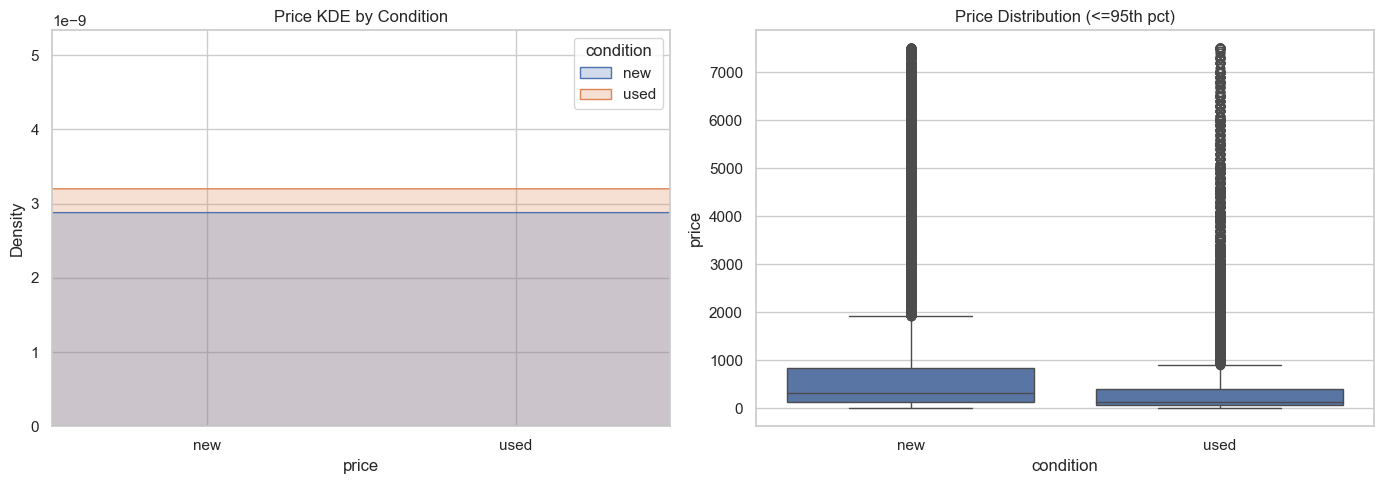

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.kdeplot(data=df_features, x='price', hue='condition', ax=axes[0], fill=True, common_norm=False)
axes[0].set_title('Price KDE by Condition')
axes[0].set_xlim(0, df_features['price'].quantile(0.95))
sns.boxplot(data=df_features[df_features['price'] <= df_features['price'].quantile(0.95)], x='condition', y='price', ax=axes[1])
axes[1].set_title('Price Distribution (<=95th pct)')
plt.tight_layout()

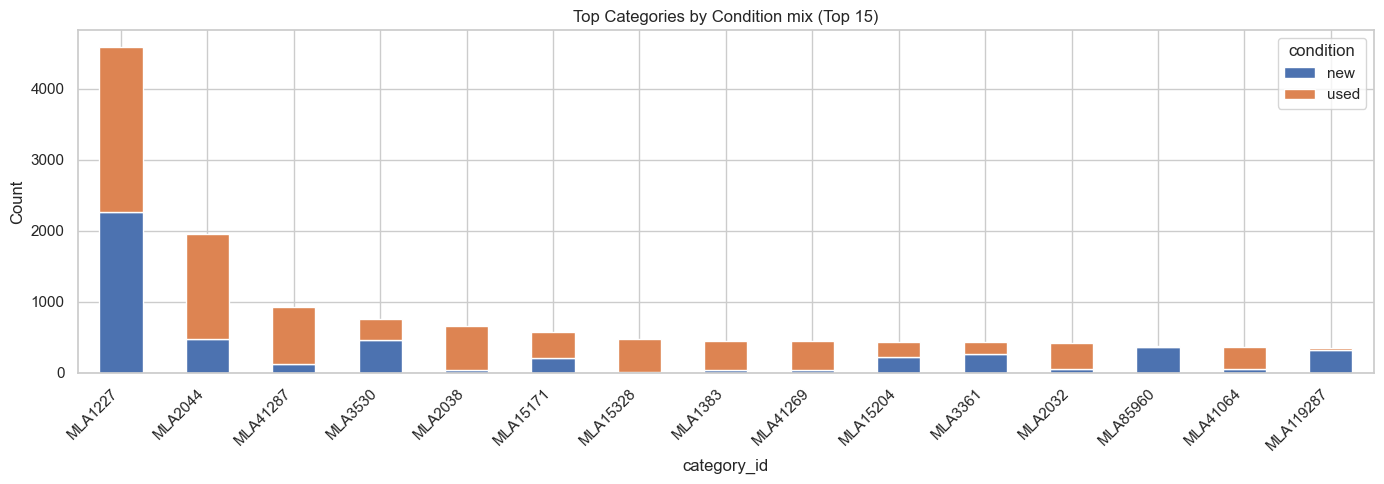

In [32]:
top_categories = (
    df_features[df_features['category_id'].notna()]
    .groupby(['category_id', 'condition'])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda df: df.sum(axis=1))
    .sort_values('total', ascending=False)
    .head(15)
)
top_categories[['new', 'used']].plot(kind='bar', stacked=True, figsize=(14, 5))
plt.title('Top Categories by Condition mix (Top 15)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [33]:
seller_group = (
    df_features.groupby(['seller_id', 'condition'])
    .size()
    .unstack(fill_value=0)
)
seller_group['total'] = seller_group.sum(axis=1)
seller_group_filtered = seller_group[seller_group['total'] >= 5]
seller_group_filtered.assign(
    condition_ratio=seller_group_filtered['new'] / seller_group_filtered['total']
).condition_ratio.describe(percentiles=[0.1, 0.5, 0.9])


count    3320.000000
mean        0.600106
std         0.444656
min         0.000000
10%         0.000000
50%         0.932576
90%         1.000000
max         1.000000
Name: condition_ratio, dtype: float64

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

processed_titles = df_features['title'].fillna('').str.lower()
vectorizer = CountVectorizer(min_df=50, stop_words='english', ngram_range=(1, 2))
title_matrix = vectorizer.fit_transform(processed_titles)
chi2_scores, _ = chi2(title_matrix, df_features['condition'])
feature_scores = sorted(zip(vectorizer.get_feature_names_out(), chi2_scores), key=lambda x: x[1], reverse=True)
feature_scores[:20]


[('la', np.float64(1683.602209531458)),
 ('nuevo', np.float64(1292.3438994406613)),
 ('vinilo', np.float64(1197.4597751632054)),
 ('revista', np.float64(1164.0198245437095)),
 ('el', np.float64(1159.5148601253788)),
 ('kit', np.float64(1108.2716918929718)),
 ('antiguo', np.float64(1073.3668529880995)),
 ('estado', np.float64(1025.9745551447954)),
 ('antigua', np.float64(1003.6094002265343)),
 ('lp', np.float64(758.756382694404)),
 ('impecable', np.float64(663.2866298205425)),
 ('amortiguador', np.float64(631.3781762714386)),
 ('delantero', np.float64(619.3613707724783)),
 ('trasero', np.float64(618.7875988774233)),
 ('para', np.float64(568.2424148682003)),
 ('freno', np.float64(499.6713873654164)),
 ('usado', np.float64(499.11169059620653)),
 ('digital', np.float64(496.9038510815886)),
 ('los', np.float64(475.67346067484345)),
 ('lote', np.float64(452.1292099215461))]

In [37]:
city_col = 'seller_address__city__name'
if city_col not in df_features.columns:
    fallback = 'seller_address.city.name'
    if fallback not in df_features.columns:
        raise KeyError('City name column not found in df_features')
    city_col = fallback

region_summary = (
    df_features[df_features[city_col].notna()]
    .groupby([city_col, 'condition'])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda df: df.sum(axis=1))
    .sort_values('total', ascending=False)
    .head(20)
)
region_summary[['new', 'used']]

condition,new,used
seller_address__city__name,,
CABA,2284,1814
Buenos Aires,1604,1816
Capital Federal,1524,1878
Palermo,2184,1171
Caballito,1254,1713
Belgrano,1009,1324
buenos aires,957,1116
capital federal,1044,828
Rosario,937,778


## Target Correlation Analysis
Quantifying relationships between engineered features and the binary target (`condition`: new vs used).

In [38]:
condition_binary = df_features['condition'].map({'new': 1, 'used': 0}).astype('int8')
condition_binary.name = 'condition_binary'
condition_binary.value_counts(normalize=True)

condition_binary
1    0.53758
0    0.46242
Name: proportion, dtype: float64

In [39]:
numeric_features = df_features.select_dtypes(include=['number']).copy()
if 'condition_binary' not in numeric_features.columns:
    numeric_features = numeric_features.join(condition_binary)
corr_series = numeric_features.corr(numeric_only=True)['condition_binary'].drop('condition_binary').sort_values(ascending=False)
corr_head = corr_series.head(15).to_frame(name='correlation')
corr_tail = corr_series.tail(15).to_frame(name='correlation')
corr_head, corr_tail

(                                       correlation
 automatic_relist                          0.185328
 seller_id                                 0.158783
 shipping__free_methods__has_key_id        0.137786
 shipping__free_methods__has_key_rule      0.137786
 shipping__free_methods__has_values        0.137786
 shipping__free_methods__len               0.137771
 shipping__free_shipping                   0.137755
 non_mercado_pago_payment_methods__len     0.114074
 seller_address__id                        0.112430
 accepts_mercadopago                       0.094073
 variations__len                           0.093334
 tags__contains_good_quality_thumbnail     0.092858
 catalog_product_id                        0.090197
 initial_quantity                          0.072873
 available_quantity                        0.072412,
                                correlation
 tags__has_values                 -0.007507
 official_store_id                -0.011805
 seller_address__longitude        -

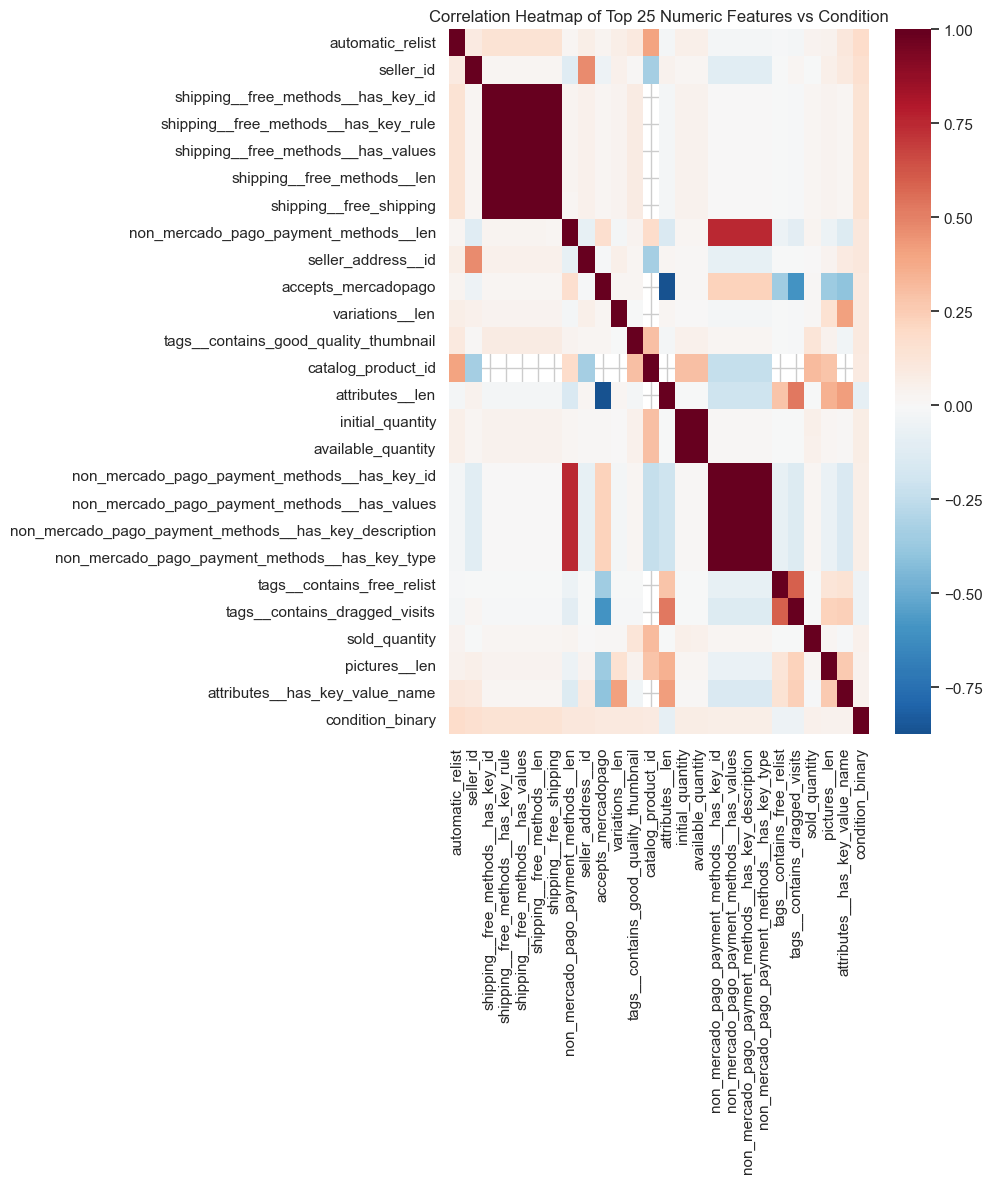

In [40]:
top_features = corr_series.abs().sort_values(ascending=False).head(25).index
plt.figure(figsize=(10, 12))
sns.heatmap(numeric_features[top_features.tolist() + ['condition_binary']].corr(),
            annot=False, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Top 25 Numeric Features vs Condition')
plt.tight_layout()

## Title Text Signals (TF‑IDF, χ², Log‑odds, Patterns)
Exploring title tokens and n‑grams associated with `condition` (new vs used).

In [42]:
titles_raw = df_features['title'].fillna('')
titles_lower = titles_raw.str.lower()
condition_binary = df_features['condition'].map({'new': 1, 'used': 0}).astype('int8')
condition_binary.value_counts(normalize=True)


condition
1    0.53758
0    0.46242
Name: proportion, dtype: float64

### TF‑IDF + χ² table
- What it shows: tokens/ngrams whose presence is most statistically associated with the target.
- Interpret: higher χ² = stronger association; it’s directionless, so use class rates or log‑odds to know if it favors “new” or “used”.
- Use: select top K terms as features (e.g., for linear models), or as a shortlist for custom regex flags.

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import pandas as pd

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=50, token_pattern=r'(?u)\b\w+\b')
X_tfidf = vectorizer.fit_transform(titles_lower)
y = condition_binary

chi2_scores, _ = chi2(X_tfidf, y)
features = vectorizer.get_feature_names_out()
chi2_df = pd.DataFrame({'term': features, 'chi2': chi2_scores}).sort_values('chi2', ascending=False)
chi2_df.head(25)


,term,chi2
1456,la,531.176864
365,antiguo,470.675861
2088,revista,459.228191
362,antigua,439.062748
2465,vinilo,436.165203
991,el,425.854743
1794,nuevo,394.873342
1072,estado,340.485663
1446,kit,327.018897
2499,x,320.263232


### Log‑odds (with smoothing)
- What it shows: signed lift toward “new” (>0) vs “used” (<0) after frequency correction.
- Interpret: magnitude ≈ strength; always check counts (support) to avoid rare token artifacts.
- Use: create binary flags for top positive and top negative terms (e.g., 50 each), or keep as priors for text-only baselines.

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

cv = CountVectorizer(ngram_range=(1,2), min_df=20, binary=True, token_pattern=r'(?u)\b\w+\b')
X_bin = cv.fit_transform(titles_lower)
terms = cv.get_feature_names_out()

# Counts per class
mask_new = (y == 1).values
mask_used = (y == 0).values
A = X_bin[mask_new].sum(axis=0).A1  # term present in new
B = X_bin[mask_used].sum(axis=0).A1 # term present in used

# Add-0.5 smoothing (Jeffreys prior)
A_s = A + 0.5
B_s = B + 0.5
N_new = mask_new.sum()
N_used = mask_used.sum()
NA_s = (N_new - A) + 0.5
NB_s = (N_used - B) + 0.5

log_odds_new = np.log(A_s/NA_s) - np.log(B_s/NB_s)
lo_df = pd.DataFrame({'term': terms, 'log_odds_new': log_odds_new, 'count_new': A, 'count_used': B})
lo_df_sorted = lo_df.sort_values('log_odds_new', ascending=False)
lo_df_sorted.head(25), lo_df_sorted.tail(25)


(                        term  log_odds_new  count_new  count_used
 763             amortiguador      7.154101        733           0
 4651              nuevo de12      6.391058        344           0
 3769                  kit x2      6.286512        310           0
 6664         x2 amortiguador      6.177147        278           0
 3075                    fric      6.113846        261           0
 3076                fric rot      6.113846        261           0
 2338                    di16      6.094447        256           0
 4653              nuevo di16      6.094447        256           0
 1073               baño tela      5.758169        183           0
 769     amortiguador trasero      5.758169        183           0
 765   amortiguador delantero      5.701946        173           0
 3533              imprimible      5.648511        164           0
 3768          kit imprimible      5.611243        158           0
 2105             de embrague      5.532290        146        

### Spanish pattern flags (nuevo/usado/seminuevo/0km/sin uso)
- What it shows: per‑condition prevalence of explicit cues.
- Interpret: large gaps mean highly predictive heuristics (e.g., “0km" → new for a car).
- Use: keep these as robust, interpretable rule features.

In [49]:
import pandas as pd
pat_map = {
    'has_nuevo': r'\bnuevo(s)?\b',
    'has_usado': r'\busad[oa]s?\b',
    'has_seminuevo': r'\bsemi[- ]?nuevo\b',
    'has_0km': r'\b0\s?km\b|\bcero\s?km\b',
    'has_sin_uso': r'\bsin\s+uso\b'
}

pattern_df = pd.DataFrame({name: titles_lower.str.contains(regex, regex=True) for name, regex in pat_map.items()})
pattern_df['condition'] = df_features['condition']
summary = pattern_df.groupby('condition').mean().T.sort_values('new', ascending=False) if 'new' in pattern_df['condition'].unique() else pattern_df.groupby('condition').mean().T
summary


/var/folders/hp/crpdxb5d1175k4n63yzzzqr80000gn/T/ipykernel_19996/3247525476.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pattern_df = pd.DataFrame({name: titles_lower.str.contains(regex, regex=True) for name, regex in pat_map.items()})


condition,new,used
has_nuevo,0.055992,0.01144
has_sin_uso,0.002176,0.001946
has_0km,0.001637,0.000324
has_usado,0.000316,0.017819
has_seminuevo,0.0,0.000043


### Spanish pattern flags from high χ² unigrams (stopwords excluded)
Derive additional regex flags from the most discriminative Spanish words, excluding common articles and prior keywords.

In [50]:

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Recompute chi2 on unigrams only
vectorizer_uni = TfidfVectorizer(ngram_range=(1,1), min_df=50, token_pattern=r'(?u)\b\w+\b')
X_uni = vectorizer_uni.fit_transform(titles_lower)
terms_uni = vectorizer_uni.get_feature_names_out()
chi2_scores_uni, _ = chi2(X_uni, condition_binary)
chi2_uni = pd.DataFrame({'term': terms_uni, 'chi2': chi2_scores_uni}).sort_values('chi2', ascending=False)

stopwords_es = {
    'el','la','los','las','un','una','unos','unas','lo','al','del','de','y','o','u','a','en','por','para','con','sin','sobre','entre','que','su','sus','mi','tu','se','es','son','mas','menos','muy','ya','no','si','como','esto','esta','estos','estas'
}
exclude_terms = {'nuevo','nuevos','nueva','nuevas','usado','usada','usados','usadas','seminuevo','semi-nuevo','0km','km','sin','uso'}

# filter terms: letters >= 3, not stopwords, not excluded
chi2_uni_f = chi2_uni.copy()
chi2_uni_f = chi2_uni_f[chi2_uni_f['term'].str.len() >= 3]
chi2_uni_f = chi2_uni_f[~chi2_uni_f['term'].isin(stopwords_es)]
chi2_uni_f = chi2_uni_f[~chi2_uni_f['term'].isin(exclude_terms)]

# pick top-K
TOP_K = 20
top_terms = chi2_uni_f.head(TOP_K)['term'].tolist()

# Build dynamic pattern flags
chi2_flag_cols = {}
for t in top_terms:
    pat = rf'\b{re.escape(t)}\b'
    col = f'chi2flag__{t}'
    chi2_flag_cols[col] = titles_lower.str.contains(pat, regex=True)

chi2_flag_df = pd.DataFrame(chi2_flag_cols)
chi2_flag_df['condition'] = df_features['condition']
chi2_flag_summary = chi2_flag_df.groupby('condition').mean().T
# Order by difference toward 'new' if present
if 'new' in chi2_flag_summary.columns and 'used' in chi2_flag_summary.columns:
    chi2_flag_summary = chi2_flag_summary.assign(diff=lambda df: df['new'] - df['used']).sort_values('diff', ascending=False)
chi2_flag_summary.head(20)


condition,new,used,diff
chi2flag__kit,0.025912,0.0008,0.025112
chi2flag__digital,0.017932,0.003049,0.014883
chi2flag__trasero,0.013989,0.000216,0.013772
chi2flag__delantero,0.013821,0.000151,0.01367
chi2flag__amortiguador,0.013635,0.0,0.013635
chi2flag__freno,0.01118,0.000173,0.011007
chi2flag__bateria,0.010454,0.001341,0.009113
chi2flag__de12,0.006436,0.000043,0.006393
chi2flag__vhs,0.000279,0.006033,-0.005754
chi2flag__argentino,0.00093,0.008369,-0.007439


### Casing/digits heuristics
- What it shows: mean uppercase ratio, digit ratio, long digit sequences by condition.
- Interpret: long digit sequences (e.g., model numbers, “0km”) often tilt “new”; excessive uppercase can be marketing for new items, but validate.
- Use: bucketized versions (e.g., quartiles) or simple thresholds as features.

In [46]:
import numpy as np
import pandas as pd

upper_ratio = titles_raw.apply(lambda s: (sum(ch.isupper() for ch in s) / max(1, len(s))))
digit_ratio = titles_raw.apply(lambda s: (sum(ch.isdigit() for ch in s) / max(1, len(s))))
long_digit_seq = titles_lower.str.contains(r'\d{4,}', regex=True)

cd_df = pd.DataFrame({
    'upper_ratio': upper_ratio,
    'digit_ratio': digit_ratio,
    'long_digit_seq': long_digit_seq.astype(int),
    'condition': df_features['condition']
})
cd_df.groupby('condition')[['upper_ratio','digit_ratio','long_digit_seq']].mean().round(3)


,upper_ratio,digit_ratio,long_digit_seq
condition,,,
new,0.139,0.052,0.123
used,0.145,0.035,0.154


### Brand terms
- What it shows: brand prevalence by condition.
- Interpret: some brands/categories skew new/used due to market turnover; can be confounded by category.
- Use: keep if brand correlates after controlling for category; otherwise interact with category (brand × category).

In [47]:
import re
import pandas as pd
brand_list = [
 'samsung','apple','sony','lg','motorola','xiaomi','huawei','nokia','lenovo','hp','dell','asus','acer',
 'nike','adidas','puma','reebok',
 'philips','bosch','whirlpool','mabe','electrolux',
 'ford','chevrolet','renault','volkswagen','toyota'
]
brand_flags = {f'brand__{b}': titles_lower.str.contains(rf'\b{re.escape(b)}\b', regex=True) for b in brand_list}
brand_df = pd.DataFrame(brand_flags)
brand_df['condition'] = df_features['condition']
brand_summary = brand_df.groupby('condition').mean().T.sort_values('new', ascending=False) if 'new' in brand_df['condition'].unique() else brand_df.groupby('condition').mean().T
brand_summary.head(20)


condition,new,used
brand__ford,0.014175,0.004433
brand__samsung,0.013468,0.006812
brand__renault,0.011756,0.002746
brand__chevrolet,0.009785,0.002898
brand__hp,0.007348,0.004109
brand__sony,0.005674,0.00413
brand__volkswagen,0.005227,0.002941
brand__lg,0.003293,0.002163
brand__toyota,0.003181,0.000822
brand__adidas,0.002716,0.001903


### Top tokens favoring each class (counts and log-odds)


Top 20 NEW tokens with counts:
                  term  count_new  count_used
          amortiguador        733           0
            nuevo de12        344           0
                kit x2        310           0
       x2 amortiguador        278           0
                  fric        261           0
              fric rot        261           0
                  di16        256           0
            nuevo di16        256           0
             baño tela        183           0
  amortiguador trasero        183           0
amortiguador delantero        173           0
            imprimible        164           0
        kit imprimible        158           0
           de embrague        146           0
                   db3        134           0
        pastilla freno        133           0
            nuevo de13        132           0
                  de13        132           0
                llanta        123           0
          lpr pastilla        122           0

T

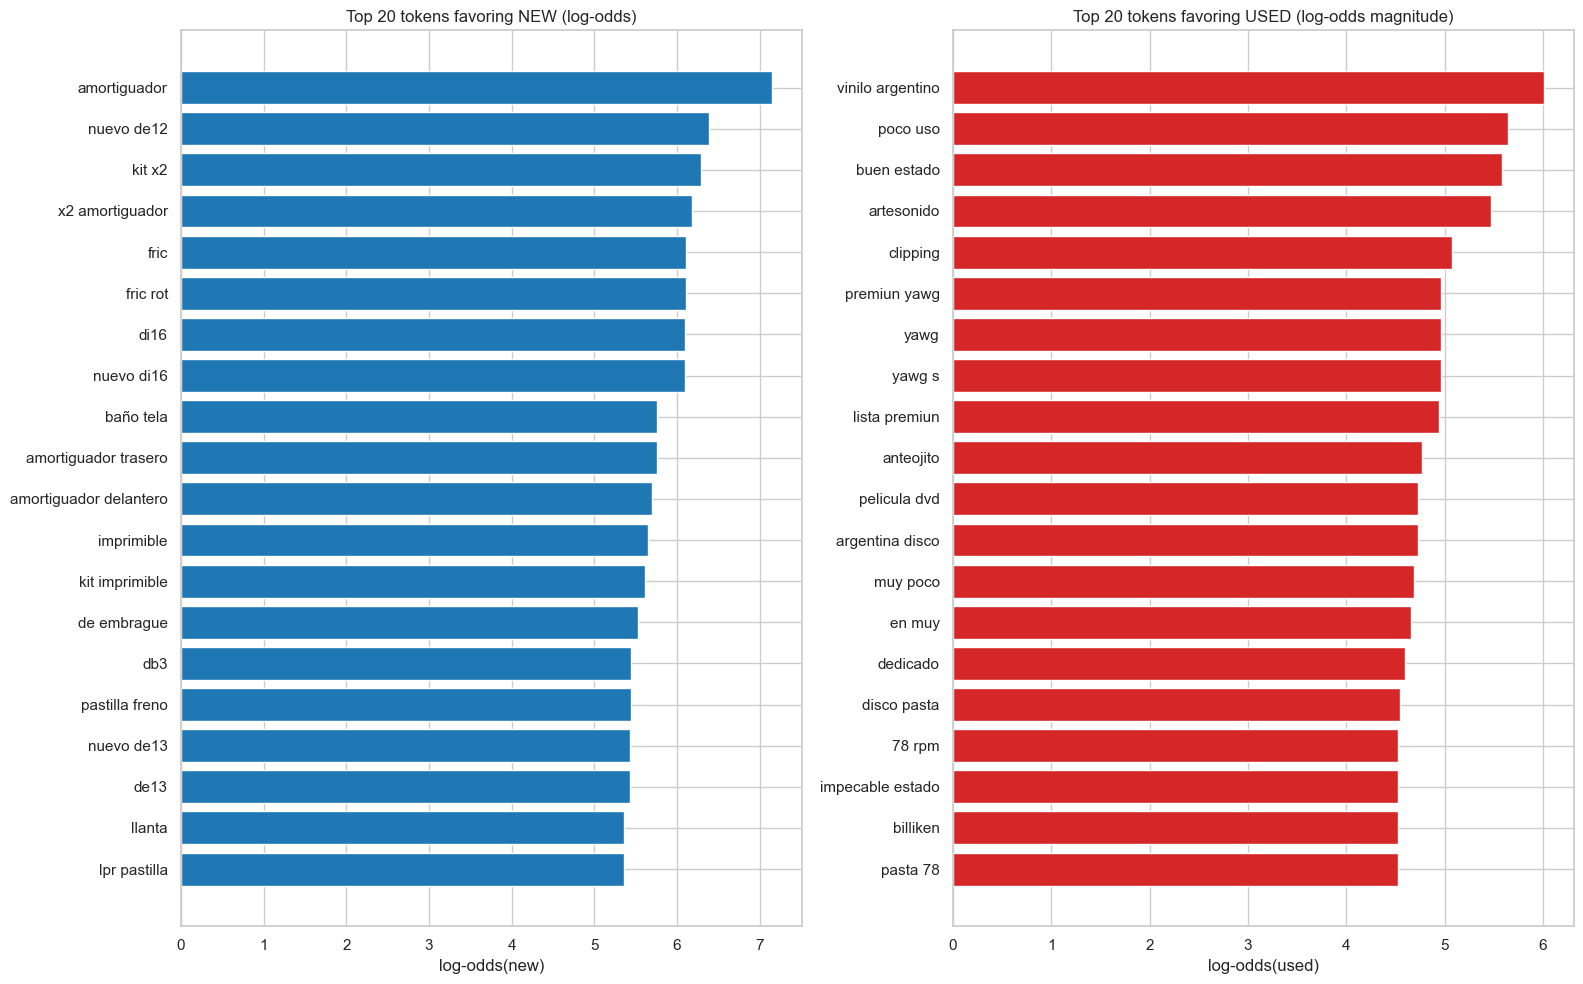

In [51]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Recompute log-odds and counts
cv = CountVectorizer(ngram_range=(1,2), min_df=20, binary=True, token_pattern=r'(?u)\b\w+\b')
X_bin = cv.fit_transform(titles_lower)
terms = cv.get_feature_names_out()
mask_new = (condition_binary == 1).values
mask_used = (condition_binary == 0).values
A = X_bin[mask_new].sum(axis=0).A1  # term present in new
B = X_bin[mask_used].sum(axis=0).A1 # term present in used
A_s, B_s = A + 0.5, B + 0.5
N_new, N_used = mask_new.sum(), mask_used.sum()
NA_s, NB_s = (N_new - A) + 0.5, (N_used - B) + 0.5
log_odds_new = np.log(A_s/NA_s) - np.log(B_s/NB_s)
lo_df_sorted = pd.DataFrame({'term': terms, 'log_odds_new': log_odds_new, 'count_new': A, 'count_used': B}).sort_values('log_odds_new', ascending=False)

head20 = lo_df_sorted.head(20)
tail20 = lo_df_sorted.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].barh(head20['term'][::-1], head20['log_odds_new'][::-1], color='tab:blue')
axes[0].set_title('Top 20 tokens favoring NEW (log-odds)')
axes[0].set_xlabel('log-odds(new)')
axes[1].barh(tail20['term'], -tail20['log_odds_new'], color='tab:red')
axes[1].set_title('Top 20 tokens favoring USED (log-odds magnitude)')
axes[1].set_xlabel('log-odds(used)')
plt.tight_layout()

print('\nTop 20 NEW tokens with counts:')
print(head20[['term','count_new','count_used']].to_string(index=False))
print('\nTop 20 USED tokens with counts:')
print(tail20[['term','count_new','count_used']].to_string(index=False))


### Consolidated regex features from patterns and χ² terms

In [52]:

import pandas as pd
import re

# Base Spanish patterns
base_pat_map = {
    'has_nuevo': r'\bnuevo(s)?\b',
    'has_usado': r'\busad[oa]s?\b',
    'has_seminuevo': r'\bsemi[- ]?nuevo\b',
    'has_0km': r'\b0\s?km\b|\bcero\s?km\b',
    'has_sin_uso': r'\bsin\s+uso\b'
}

# Dynamic chi2-driven flags if available
try:
    top_terms
except NameError:
    top_terms = []
chi2_map = {f'chi2flag__{t}': rf'\b{re.escape(t)}\b' for t in top_terms}
all_map = {**base_pat_map, **chi2_map}

flag_df = pd.DataFrame({name: titles_lower.str.contains(pat, regex=True) for name, pat in all_map.items()})
flag_df['condition_binary'] = condition_binary
flag_df.head(3)


/var/folders/hp/crpdxb5d1175k4n63yzzzqr80000gn/T/ipykernel_19996/2088404977.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  flag_df = pd.DataFrame({name: titles_lower.str.contains(pat, regex=True) for name, pat in all_map.items()})


,has_nuevo,has_usado,has_seminuevo,has_0km,has_sin_uso,chi2flag__vinilo,chi2flag__antiguo,chi2flag__revista,chi2flag__antigua,chi2flag__estado,chi2flag__kit,chi2flag__impecable,chi2flag__digital,chi2flag__amortiguador,chi2flag__delantero,chi2flag__trasero,chi2flag__historia,chi2flag__freno,chi2flag__lote,chi2flag__buen,chi2flag__año,chi2flag__argentino,chi2flag__bateria,chi2flag__de12,chi2flag__vhs,condition_binary
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,0


### Fast CV baselines (pattern flags and TF‑IDF)

In [53]:

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline 1: pattern flags only
X_flags = flag_df.drop(columns=['condition_binary']).astype('int8') if 'flag_df' in globals() else None
y = condition_binary
if X_flags is not None and X_flags.shape[1] > 0:
    clf_flags = LogisticRegression(max_iter=300)
    acc_scores = cross_val_score(clf_flags, X_flags, y, cv=skf, scoring='accuracy')
    auc_scores = cross_val_score(clf_flags, X_flags, y, cv=skf, scoring='roc_auc')
    print('Flags-only CV: accuracy', np.round(acc_scores.mean(), 4), '+/-', np.round(acc_scores.std(), 4), 'AUC', np.round(auc_scores.mean(), 4))
else:
    print('Flags-only CV: skipped (no flags)')

# Baseline 2: TF-IDF unigrams+bigrams
pipe_tfidf = (TfidfVectorizer(ngram_range=(1,2), min_df=50, token_pattern=r'(?u)\b\w+\b'), LogisticRegression(max_iter=400))
# Use cross_val_score manually with pipelined steps for performance clarity
vectorizer, clf = pipe_tfidf
X_text = vectorizer.fit_transform(titles_lower)
acc_scores2 = cross_val_score(clf, X_text, y, cv=skf, scoring='accuracy')
auc_scores2 = cross_val_score(clf, X_text, y, cv=skf, scoring='roc_auc')
print('TF-IDF CV: accuracy', np.round(acc_scores2.mean(), 4), '+/-', np.round(acc_scores2.std(), 4), 'AUC', np.round(auc_scores2.mean(), 4))


Flags-only CV: accuracy 0.6201 +/- 0.0017 AUC 0.6412
TF-IDF CV: accuracy 0.7872 +/- 0.0033 AUC 0.8693


## Description Text Signals
Mirror the title text analysis using item descriptions, if present.

In [54]:
# Detect likely description fields in the flattened dataset
desc_cols = [c for c in df_features.columns if 'description' in c or c.endswith('__plain_text') or c.endswith('__text')]
desc_cols


['non_mercado_pago_payment_methods__has_key_description',
 'descriptions__len',
 'descriptions__has_values',
 'descriptions__has_key_id']

In [55]:
# Assemble a single description series (text-only)
import pandas as pd
textual_cols = []
for col in df_features.columns:
    name = str(col)
    if not (name.endswith('__plain_text') or name.endswith('__text') or 'description' in name):
        continue
    if name.endswith('__len') or '__has_' in name or name.endswith('__id') or name == 'id':
        continue
    if str(df_features[col].dtype).startswith('string') or str(df_features[col].dtype) == 'object':
        textual_cols.append(col)
if textual_cols:
    frames = [df_features[c].astype('string').fillna('') for c in textual_cols]
    descriptions = pd.concat(frames, axis=1).agg(' '.join, axis=1).str.strip()
else:
    descriptions = pd.Series([''] * len(df_features), index=df_features.index)
descriptions = descriptions.fillna('')
descriptions_lower = descriptions.str.lower()
descriptions_lower.head(3)


0    1 1 1 1
1    1 1 1 1
2    1 1 1 1
dtype: object

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
import pandas as pd

if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    vec_d = TfidfVectorizer(ngram_range=(1,2), min_df=50, token_pattern=r'(?u)\b\w+\b')
    Xd = vec_d.fit_transform(descriptions_lower)
    y = condition_binary
    chi2_scores_d, _ = chi2(Xd, y)
    feats_d = vec_d.get_feature_names_out()
    chi2_desc = pd.DataFrame({'term': feats_d, 'chi2': chi2_scores_d}).sort_values('chi2', ascending=False)
    chi2_desc.head(25)


In [57]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    cvd = CountVectorizer(ngram_range=(1,2), min_df=20, binary=True, token_pattern=r'(?u)\b\w+\b')
    Xd_bin = cvd.fit_transform(descriptions_lower)
    terms_d = cvd.get_feature_names_out()
    mask_new = (condition_binary == 1).values
    mask_used = (condition_binary == 0).values
    A = Xd_bin[mask_new].sum(axis=0).A1
    B = Xd_bin[mask_used].sum(axis=0).A1
    A_s, B_s = A + 0.5, B + 0.5
    N_new, N_used = mask_new.sum(), mask_used.sum()
    NA_s, NB_s = (N_new - A) + 0.5, (N_used - B) + 0.5
    log_odds_new_d = np.log(A_s/NA_s) - np.log(B_s/NB_s)
    lo_desc_sorted = pd.DataFrame({'term': terms_d, 'log_odds_new': log_odds_new_d, 'count_new': A, 'count_used': B}).sort_values('log_odds_new', ascending=False)
    lo_desc_sorted.head(20), lo_desc_sorted.tail(20)


In [58]:
import re
import pandas as pd
pat_map_d = {
    'has_nuevo_d': r'\bnuevo(s)?\b',
    'has_usado_d': r'\busad[oa]s?\b',
    'has_seminuevo_d': r'\bsemi[- ]?nuevo\b',
    'has_0km_d': r'\b0\s?km\b|\bcero\s?km\b',
    'has_sin_uso_d': r'\bsin\s+uso\b'
}
if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    pattern_df_d = pd.DataFrame({name: descriptions_lower.str.contains(regex, regex=True) for name, regex in pat_map_d.items()})
    pattern_df_d['condition'] = df_features['condition']
    pattern_df_d.groupby('condition').mean().T


/var/folders/hp/crpdxb5d1175k4n63yzzzqr80000gn/T/ipykernel_19996/499011465.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pattern_df_d = pd.DataFrame({name: descriptions_lower.str.contains(regex, regex=True) for name, regex in pat_map_d.items()})


### Description: Top tokens favoring each class (counts and log-odds)


Description NEW tokens with counts:
term  count_new  count_used
   1      53191       45450
 1 1      52608       44704
 0 1      14400       14800
   0      15550       16338
 1 0        583         746
 0 0       1150        1538

Description USED tokens with counts:
term  count_new  count_used
   1      53191       45450
 1 1      52608       44704
 0 1      14400       14800
   0      15550       16338
 1 0        583         746
 0 0       1150        1538


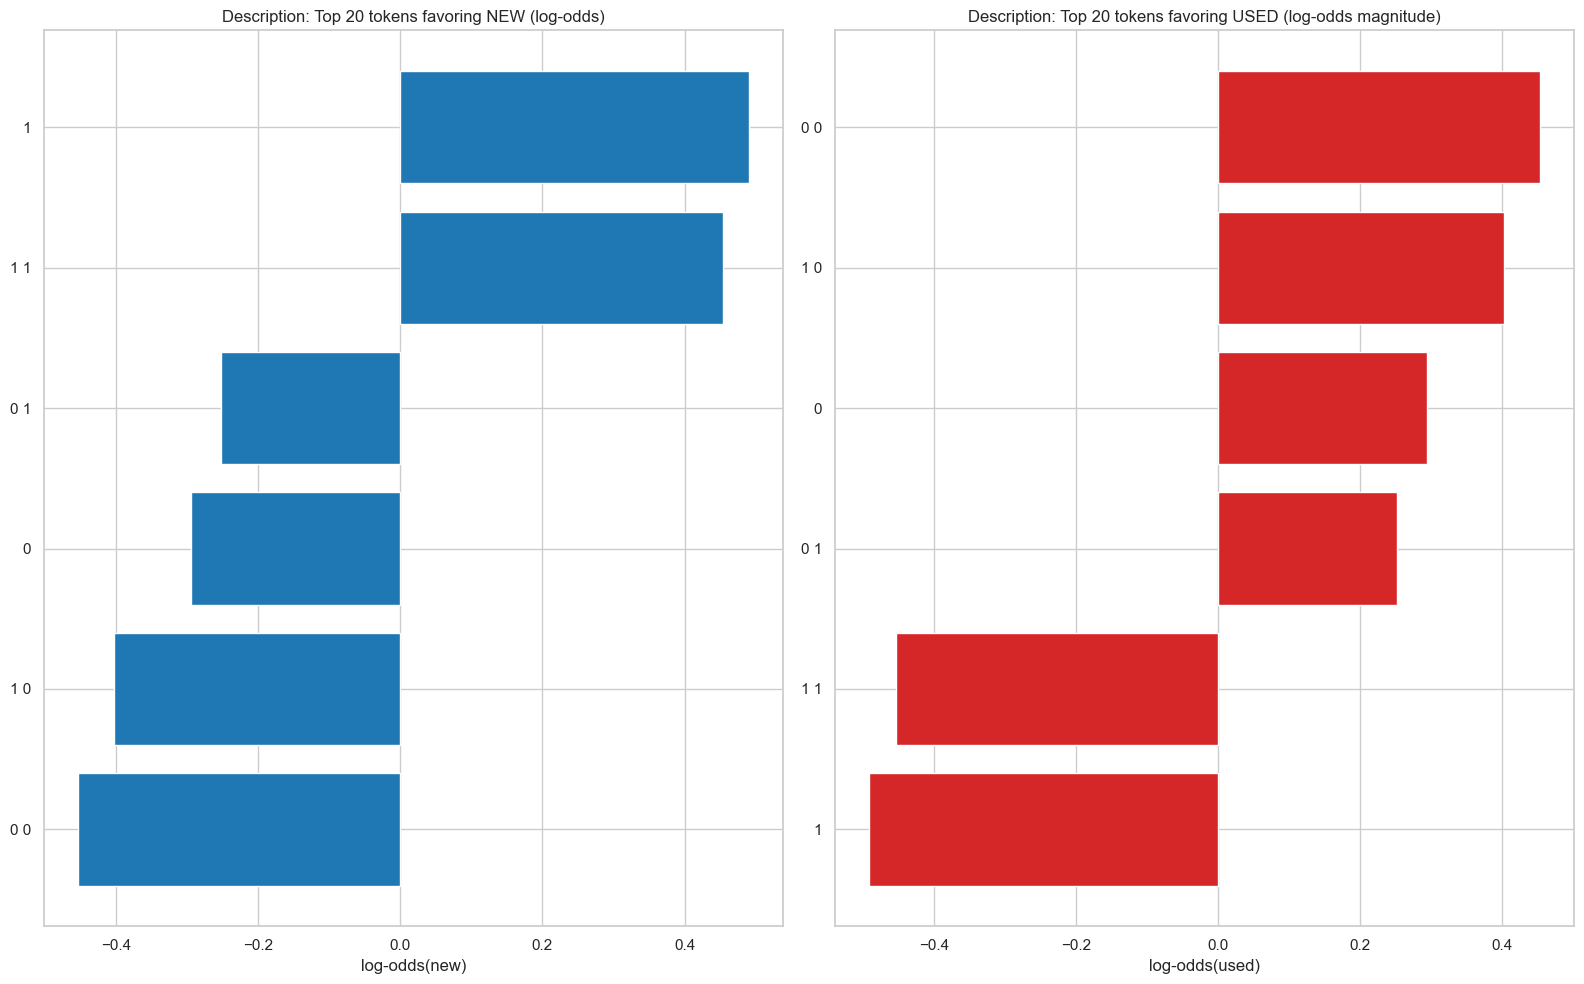

In [59]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    cvd_plot = CountVectorizer(ngram_range=(1,2), min_df=20, binary=True, token_pattern=r'(?u)\b\w+\b')
    Xd_bin_plot = cvd_plot.fit_transform(descriptions_lower)
    terms_dp = cvd_plot.get_feature_names_out()
    mask_new = (condition_binary == 1).values
    mask_used = (condition_binary == 0).values
    A = Xd_bin_plot[mask_new].sum(axis=0).A1
    B = Xd_bin_plot[mask_used].sum(axis=0).A1
    A_s, B_s = A + 0.5, B + 0.5
    N_new, N_used = mask_new.sum(), mask_used.sum()
    NA_s, NB_s = (N_new - A) + 0.5, (N_used - B) + 0.5
    log_odds_new_d = np.log(A_s/NA_s) - np.log(B_s/NB_s)
    lo_desc_sorted_plot = pd.DataFrame({'term': terms_dp, 'log_odds_new': log_odds_new_d, 'count_new': A, 'count_used': B}).sort_values('log_odds_new', ascending=False)

    head20 = lo_desc_sorted_plot.head(20)
    tail20 = lo_desc_sorted_plot.tail(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    axes[0].barh(head20['term'][::-1], head20['log_odds_new'][::-1], color='tab:blue')
    axes[0].set_title('Description: Top 20 tokens favoring NEW (log-odds)')
    axes[0].set_xlabel('log-odds(new)')
    axes[1].barh(tail20['term'], -tail20['log_odds_new'], color='tab:red')
    axes[1].set_title('Description: Top 20 tokens favoring USED (log-odds magnitude)')
    axes[1].set_xlabel('log-odds(used)')
    plt.tight_layout()

    print('\nDescription NEW tokens with counts:')
    print(head20[['term','count_new','count_used']].to_string(index=False))
    print('\nDescription USED tokens with counts:')
    print(tail20[['term','count_new','count_used']].to_string(index=False))


### Description: Top-K tokens tables (mirroring titles)

In [65]:

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

TOP_K = 20

if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    cvd = CountVectorizer(ngram_range=(1,2), min_df=20, binary=True, token_pattern=r'(?u)\b\w+\b')
    Xd_bin = cvd.fit_transform(descriptions_lower)
    terms_d = cvd.get_feature_names_out()

    mask_new = (condition_binary == 1).values
    mask_used = (condition_binary == 0).values

    A = Xd_bin[mask_new].sum(axis=0).A1  # present in NEW
    B = Xd_bin[mask_used].sum(axis=0).A1 # present in USED

    # Log-odds with 0.5 smoothing
    A_s, B_s = A + 0.5, B + 0.5
    N_new, N_used = mask_new.sum(), mask_used.sum()
    NA_s, NB_s = (N_new - A) + 0.5, (N_used - B) + 0.5
    log_odds_new = np.log(A_s/NA_s) - np.log(B_s/NB_s)

    df_desc_terms = pd.DataFrame({
        'term': terms_d,
        'log_odds_new': log_odds_new,
        'count_new': A,
        'count_used': B,
    }).sort_values('log_odds_new', ascending=False)

    desc_top_new = df_desc_terms.head(TOP_K)[['term','count_new','count_used','log_odds_new']]
    desc_top_used = df_desc_terms.tail(TOP_K)[['term','count_new','count_used','log_odds_new']]

    print('\nTop', TOP_K, 'Description tokens favoring NEW:')
    display(desc_top_new.reset_index(drop=True))
    print('\nTop', TOP_K, 'Description tokens favoring USED:')
    display(desc_top_used.reset_index(drop=True))



Top 20 Description tokens favoring NEW:


,term,count_new,count_used,log_odds_new
0,1,53191,45450,0.491227
1,1 1,52608,44704,0.453415
2,0 1,14400,14800,-0.251950
3,0,15550,16338,-0.294481
4,1 0,583,746,-0.402314
5,0 0,1150,1538,-0.453415



Top 20 Description tokens favoring USED:


,term,count_new,count_used,log_odds_new
0,1,53191,45450,0.491227
1,1 1,52608,44704,0.453415
2,0 1,14400,14800,-0.251950
3,0,15550,16338,-0.294481
4,1 0,583,746,-0.402314
5,0 0,1150,1538,-0.453415


### Description: Casing and digits heuristics

In [60]:

import pandas as pd
if descriptions.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    upper_ratio_d = descriptions.apply(lambda s: (sum(ch.isupper() for ch in s) / max(1, len(s))))
    digit_ratio_d = descriptions.apply(lambda s: (sum(ch.isdigit() for ch in s) / max(1, len(s))))
    long_digit_seq_d = descriptions_lower.str.contains(r'\d{4,}', regex=True)

    cd_df_d = pd.DataFrame({
        'upper_ratio_d': upper_ratio_d,
        'digit_ratio_d': digit_ratio_d,
        'long_digit_seq_d': long_digit_seq_d.astype(int),
        'condition': df_features['condition']
    })
    cd_df_d.groupby('condition')[['upper_ratio_d','digit_ratio_d','long_digit_seq_d']].mean().round(3)


### Description: Brand terms prevalence

In [61]:

import re
import pandas as pd
brand_list = [
 'samsung','apple','sony','lg','motorola','xiaomi','huawei','nokia','lenovo','hp','dell','asus','acer',
 'nike','adidas','puma','reebok',
 'philips','bosch','whirlpool','mabe','electrolux',
 'ford','chevrolet','renault','volkswagen','toyota'
]
if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    brand_flags_d = {f'brand_d__{b}': descriptions_lower.str.contains(rf'\b{re.escape(b)}\b', regex=True) for b in brand_list}
    brand_df_d = pd.DataFrame(brand_flags_d)
    brand_df_d['condition'] = df_features['condition']
    brand_summary_d = brand_df_d.groupby('condition').mean().T
    if 'new' in brand_summary_d.columns:
        brand_summary_d = brand_summary_d.sort_values('new', ascending=False)
    brand_summary_d.head(20)


### Description: Spanish pattern flags from high χ² unigrams

In [64]:

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

if descriptions_lower.str.len().sum() == 0:
    print('No description text available to analyze.')
else:
    vecd_uni = TfidfVectorizer(ngram_range=(1,1), min_df=50, token_pattern=r'(?u)\b\w+\b')
    Xdu = vecd_uni.fit_transform(descriptions_lower)
    terms_du = vecd_uni.get_feature_names_out()
    chi2_scores_du, _ = chi2(Xdu, condition_binary)
    chi2_du = pd.DataFrame({'term': terms_du, 'chi2': chi2_scores_du}).sort_values('chi2', ascending=False)

    stopwords_es = {
        'el','la','los','las','un','una','unos','unas','lo','al','del','de','y','o','u','a','en','por','para','con','sin','sobre','entre','que','su','sus','mi','tu','se','es','son','mas','menos','muy','ya','no','si','como','esto','esta','estos','estas'
    }
    exclude_terms = {'nuevo','nuevos','nueva','nuevas','usado','usada','usados','usadas','seminuevo','semi-nuevo','0km','km','sin','uso'}

    chi2_du_f = chi2_du.copy()
    chi2_du_f = chi2_du_f[chi2_du_f['term'].str.len() >= 3]
    chi2_du_f = chi2_du_f[~chi2_du_f['term'].isin(stopwords_es)]
    chi2_du_f = chi2_du_f[~chi2_du_f['term'].isin(exclude_terms)]

    TOP_K = 20
    desc_top_terms = chi2_du_f.head(TOP_K)['term'].tolist()

    chi2_map_d = {f'chi2dflag__{t}': rf'\b{re.escape(t)}\b' for t in desc_top_terms}
    flag_df_d = pd.DataFrame({name: descriptions_lower.str.contains(pat, regex=True) for name, pat in chi2_map_d.items()})
    flag_df_d['condition'] = df_features['condition']
    flag_summary_d = flag_df_d.groupby('condition').mean().T
    if 'new' in flag_summary_d.columns and 'used' in flag_summary_d.columns:
        flag_summary_d = flag_summary_d.assign(diff=lambda df: df['new'] - df['used']).sort_values('diff', ascending=False)
    flag_summary_d.head(20)


## Price normalization and discount features

,count,mean,std,min,25%,50%,75%,max
log_price,100000.0,5.779,1.755,0.610,4.511,5.525,6.686,2.152200e+01
price_over_base,100000.0,1.087,21.076,1.000,1.000,1.000,1.000,6.585000e+03
has_original_price,100000.0,0.001,0.038,0.000,0.000,0.000,0.000,1.000000e+00
discount_rate,143.0,0.245,0.119,0.000,0.198,0.220,0.300,7.350000e-01
price_z_iqr,95968.0,115.221,35207.543,-1678.533,-0.333,0.000,0.693,1.090661e+07
price_rank_pct_in_cat,100000.0,0.555,0.299,0.000,0.301,0.550,0.816,1.000000e+00


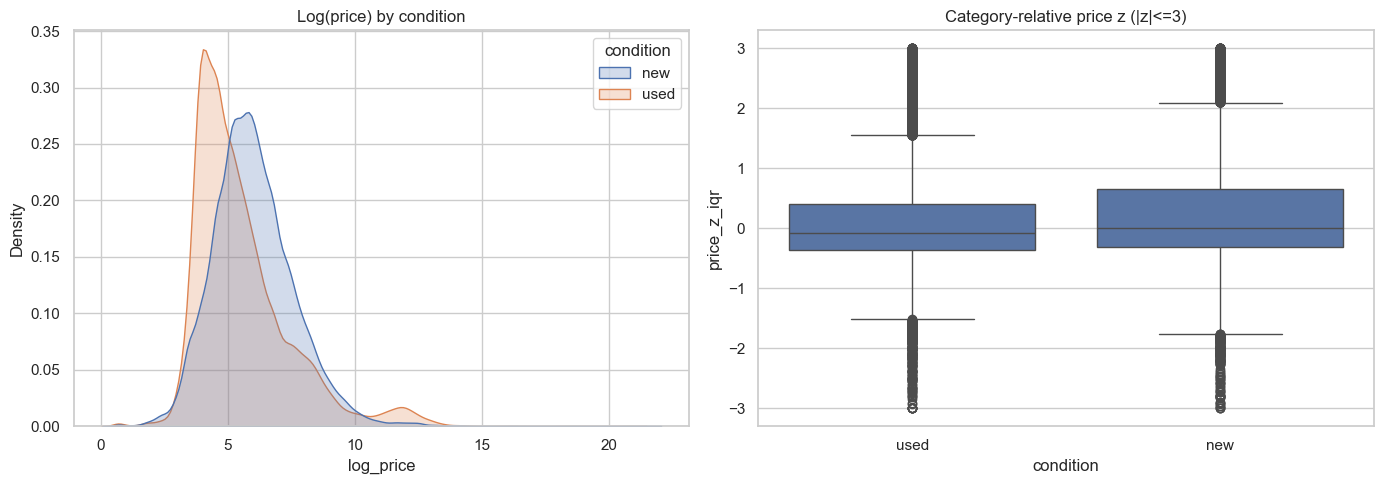

In [66]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

price_df = df_features.copy()

# Basic transforms
price_df['log_price'] = np.log1p(price_df['price'])
price_df['price_over_base'] = np.where(price_df['base_price'].fillna(0) > 0, price_df['price'] / price_df['base_price'], np.nan)
price_df['has_original_price'] = price_df.get('original_price', pd.Series(index=price_df.index)).notna().astype(int)
price_df['discount_rate'] = np.where(price_df.get('original_price', pd.Series(index=price_df.index)).fillna(0) > 0,
                                     1 - (price_df['price'] / price_df['original_price']), np.nan)

# Category-relative stats
cat_group = price_df.groupby('category_id')['price']
q25 = cat_group.transform(lambda s: s.quantile(0.25))
median = cat_group.transform('median')
q75 = cat_group.transform(lambda s: s.quantile(0.75))
iqr = (q75 - q25).replace(0, np.nan)
price_df['price_med_by_cat'] = median
price_df['price_iqr_by_cat'] = iqr
price_df['price_z_iqr'] = (price_df['price'] - median) / iqr
# Within-category rank percentile as robust quantile bin
price_df['price_rank_pct_in_cat'] = price_df.groupby('category_id')['price'].rank(pct=True)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.kdeplot(data=price_df, x='log_price', hue='condition', fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Log(price) by condition')
sns.boxplot(data=price_df[price_df['price_z_iqr'].between(-3, 3)], x='condition', y='price_z_iqr', ax=axes[1])
axes[1].set_title('Category-relative price z (|z|<=3)')
plt.tight_layout()

price_df[['log_price','price_over_base','has_original_price','discount_rate','price_z_iqr','price_rank_pct_in_cat']].describe().T.round(3)


## Inventory and sales velocity

In [67]:

import pandas as pd
import numpy as np

inv_df = df_features.copy()
for col in ['start_time','last_updated','stop_time']:
    if col in inv_df:
        inv_df[col] = pd.to_datetime(inv_df[col], errors='coerce')

ref_time = inv_df['last_updated'].max() if 'last_updated' in inv_df else pd.Timestamp.utcnow()
days_live = (ref_time - inv_df.get('start_time', pd.Series(index=inv_df.index))).dt.days
inv_df['days_live'] = days_live.clip(lower=1)
inv_df['sold_per_day'] = inv_df.get('sold_quantity', pd.Series(index=inv_df.index)).fillna(0) / inv_df['days_live']
inv_df['avail_bin'] = pd.cut(inv_df.get('available_quantity', pd.Series(index=inv_df.index)).fillna(-1), bins=[-1,0,1,5,10,50,100,1000], labels=False, include_lowest=True)
inv_df['auto_relist'] = inv_df.get('automatic_relist', pd.Series(index=inv_df.index)).fillna(False).astype(int)

inv_df.groupby('condition')[['sold_per_day']].median().T.round(4)


condition,new,used
sold_per_day,0.0,0.0


## Seller priors (smoothed) and entropy

In [68]:

import numpy as np
import pandas as pd

sdf = df_features[['seller_id','condition']].copy()
prior_p = (sdf['condition'] == 'new').mean()
K = 20  # strength of prior
seller_stats = (
    sdf.assign(is_new=(sdf['condition']=='new').astype(int))
       .groupby('seller_id')['is_new']
       .agg(['sum','count'])
       .rename(columns={'sum':'num_new','count':'num_total'})
)
seller_stats['share_new'] = seller_stats['num_new'] / seller_stats['num_total']
seller_stats['share_new_smoothed'] = (seller_stats['num_new'] + prior_p*K) / (seller_stats['num_total'] + K)
# entropy of conditions per seller
cond_counts = sdf.pivot_table(index='seller_id', columns='condition', aggfunc=len, fill_value=0)
probs = cond_counts.div(cond_counts.sum(axis=1), axis=0).replace(0, np.nan)
seller_stats['entropy'] = - (probs * np.log(probs)).sum(axis=1)

seller_stats.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
num_new,35916.0,1.497,8.571,0.000,0.000,1.00,1.00,874.000
num_total,35916.0,2.784,11.074,1.000,1.000,1.00,2.00,933.000
share_new,35916.0,0.536,0.487,0.000,0.000,1.00,1.00,1.000
share_new_smoothed,35916.0,0.539,0.063,0.027,0.512,0.56,0.56,0.988
entropy,35916.0,0.033,0.138,-0.000,-0.000,-0.00,0.00,0.693


## Listing type and shipping

In [69]:

import pandas as pd
cols = {
    'listing_type_id': 'listing_type_id',
    'ship_mode': 'shipping__mode' if 'shipping__mode' in df_features.columns else 'shipping.mode',
    'free_shipping': 'shipping__free_shipping' if 'shipping__free_shipping' in df_features.columns else 'shipping.free_shipping',
    'local_pick_up': 'shipping__local_pick_up' if 'shipping__local_pick_up' in df_features.columns else 'shipping.local_pick_up',
    'dimensions': 'shipping__dimensions' if 'shipping__dimensions' in df_features.columns else 'shipping.dimensions',
    'free_methods_len': 'shipping__free_methods__len' if 'shipping__free_methods__len' in df_features.columns else None,
}
ship_df = pd.DataFrame(index=df_features.index)
for k, c in cols.items():
    if c is not None and c in df_features.columns:
        ship_df[k] = df_features[c]
ship_df['has_dimensions'] = ship_df.get('dimensions', pd.Series(index=ship_df.index)).notna().astype(int)
ship_df['tags_len'] = df_features.get('tags__len', pd.Series(index=ship_df.index)).fillna(0)
ship_df['condition'] = df_features['condition']

summary = ship_df.groupby('condition')[['free_shipping','local_pick_up','has_dimensions','tags_len']].mean().round(3)
summary


,free_shipping,local_pick_up,has_dimensions,tags_len
condition,,,,
new,0.052,0.811,0.0,0.771
used,0.005,0.777,0.0,0.763


## Images and attributes

In [70]:

import pandas as pd
mdf = pd.DataFrame({
    'picture_count': df_features.get('pictures__len', pd.Series(index=df_features.index)).fillna(0),
    'attributes_count': df_features.get('attributes__len', pd.Series(index=df_features.index)).fillna(0),
    'variation_count': df_features.get('variations__len', pd.Series(index=df_features.index)).fillna(0),
    'condition': df_features['condition']
})
mdf.groupby('condition')[['picture_count','attributes_count','variation_count']].median().round(2)


,picture_count,attributes_count,variation_count
condition,,,
new,3.0,0.0,0.0
used,2.0,0.0,0.0


## Geography: state/city condition rates and category control

In [71]:

import pandas as pd

state_col = 'seller_address__state__name' if 'seller_address__state__name' in df_features.columns else 'seller_address.state.name'
city_col = 'seller_address__city__name' if 'seller_address__city__name' in df_features.columns else 'seller_address.city.name'

geo_df = df_features[[state_col, city_col, 'category_id', 'condition']].copy()
state_rates = (
    geo_df.groupby([state_col, 'condition']).size().unstack(fill_value=0)
          .assign(total=lambda x: x.sum(axis=1))
          .assign(rate_new=lambda x: x.get('new',0)/x['total'])
          .sort_values('total', ascending=False).head(20)
)
# Category x city pivot (top 10 cities by volume)
top_cities = geo_df[city_col].value_counts().head(10).index
cat_city = (
    geo_df[geo_df[city_col].isin(top_cities)]
      .pivot_table(index=[city_col, 'category_id'], columns='condition', aggfunc=len, fill_value=0)
)
state_rates[['total','rate_new']].head(10), cat_city.head(10)


(condition                    total  rate_new
 seller_address__state__name                 
 Capital Federal              57854  0.538096
 Buenos Aires                 35013  0.527376
 Santa Fe                      2672  0.510105
 Córdoba                       1908  0.668763
 Mendoza                        450  0.553333
 Chubut                         375  0.810667
 Entre Ríos                     287  0.439024
 Tucumán                        237  0.611814
 San Juan                       151  0.688742
 Salta                          146  0.602740,
                                        seller_address__state__name     
 condition                                                      new used
 seller_address__city__name category_id                                 
 Belgrano                   MLA10072                              1    0
                            MLA10076                              0    1
                            MLA10096                              2    0
         

## Time effects: cohorts and recency

In [72]:

import pandas as pd

tdf = df_features.copy()
for col in ['start_time','last_updated']:
    if col in tdf:
        tdf[col] = pd.to_datetime(tdf[col], errors='coerce')

tdf['cohort_month'] = tdf.get('start_time').dt.to_period('M') if 'start_time' in tdf else pd.PeriodIndex([None]*len(tdf))
cohort_rates = tdf.groupby(['cohort_month','condition']).size().unstack(fill_value=0)
if not cohort_rates.empty:
    cohort_rates['total'] = cohort_rates.sum(axis=1)
    cohort_rates['rate_new'] = cohort_rates.get('new',0)/cohort_rates['total']

now_ts = tdf['last_updated'].max() if 'last_updated' in tdf else pd.Timestamp.utcnow()
tdf['recency_days'] = (now_ts - tdf.get('last_updated', pd.Series(index=tdf.index))).dt.days

tdf[['recency_days']].describe().T.round(2), cohort_rates.tail(6)


/var/folders/hp/crpdxb5d1175k4n63yzzzqr80000gn/T/ipykernel_19996/3996118408.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tdf['cohort_month'] = tdf.get('start_time').dt.to_period('M') if 'start_time' in tdf else pd.PeriodIndex([None]*len(tdf))


(                 count   mean    std  min  25%   50%   75%    max
 recency_days  100000.0  21.31  16.91  0.0  7.0  18.0  33.0  337.0,
 condition       new   used  total  rate_new
 cohort_month                               
 2015-05          25     37     62  0.403226
 2015-06          41     33     74  0.554054
 2015-07         121    135    256  0.472656
 2015-08       12184  10695  22879  0.532541
 2015-09       26218  22658  48876  0.536419
 2015-10       15060  12555  27615  0.545356)

## Missingness indicators vs target

In [73]:

import pandas as pd
cols_to_check = [c for c in ['warranty','catalog_product_id','official_store_id','subtitle','video_id'] if c in df_features.columns]
miss_df = pd.DataFrame({f'isna__{c}': df_features[c].isna().astype(int) for c in cols_to_check})
miss_df['condition'] = df_features['condition']
miss_df.groupby('condition').mean().T.sort_values('new' if 'new' in miss_df['condition'].unique() else 'used', ascending=False).round(3)


condition,new,used
isna__subtitle,1.000,1.000
isna__catalog_product_id,1.000,1.000
isna__official_store_id,0.985,1.000
isna__video_id,0.957,0.985
isna__warranty,0.549,0.679


## Category interactions and tree-based importance (numeric only)

In [74]:

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

ci = df_features.copy()
# Price residual within category
if 'price' in ci and 'category_id' in ci:
    med = ci.groupby('category_id')['price'].transform('median')
    ci['price_resid_cat'] = ci['price'] - med
# Simple interaction: shipping mode indicator if present
ship_mode_col = 'shipping__mode' if 'shipping__mode' in ci.columns else ('shipping.mode' if 'shipping.mode' in ci.columns else None)
if ship_mode_col:
    ci['ship_me2'] = (ci[ship_mode_col].astype('string').fillna('') == 'me2').astype(int)

# Build numeric matrix
y = (ci['condition'] == 'new').astype(int)
X_num = ci.select_dtypes(include=['number']).fillna(0)
if X_num.shape[1] > 0:
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(rf, X_num, y, cv=skf, scoring='accuracy')
    rf.fit(X_num, y)
    importances = pd.Series(rf.feature_importances_, index=X_num.columns).sort_values(ascending=False).head(20)
    print('RF (numeric-only) CV accuracy:', np.round(acc.mean(), 4), '+/-', np.round(acc.std(), 4))
    importances
else:
    print('No numeric features found for importance check.')


RF (numeric-only) CV accuracy: 0.8528 +/- 0.0015


## Partial dependence for top numeric drivers

/Users/raulsallesdepadua/Documents/Career-Mgmt/MELI/technical_challenge_DS_GenAI/.venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 11 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/raulsallesdepadua/Documents/Career-Mgmt/MELI/technical_challenge_DS_GenAI/.venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 13 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will

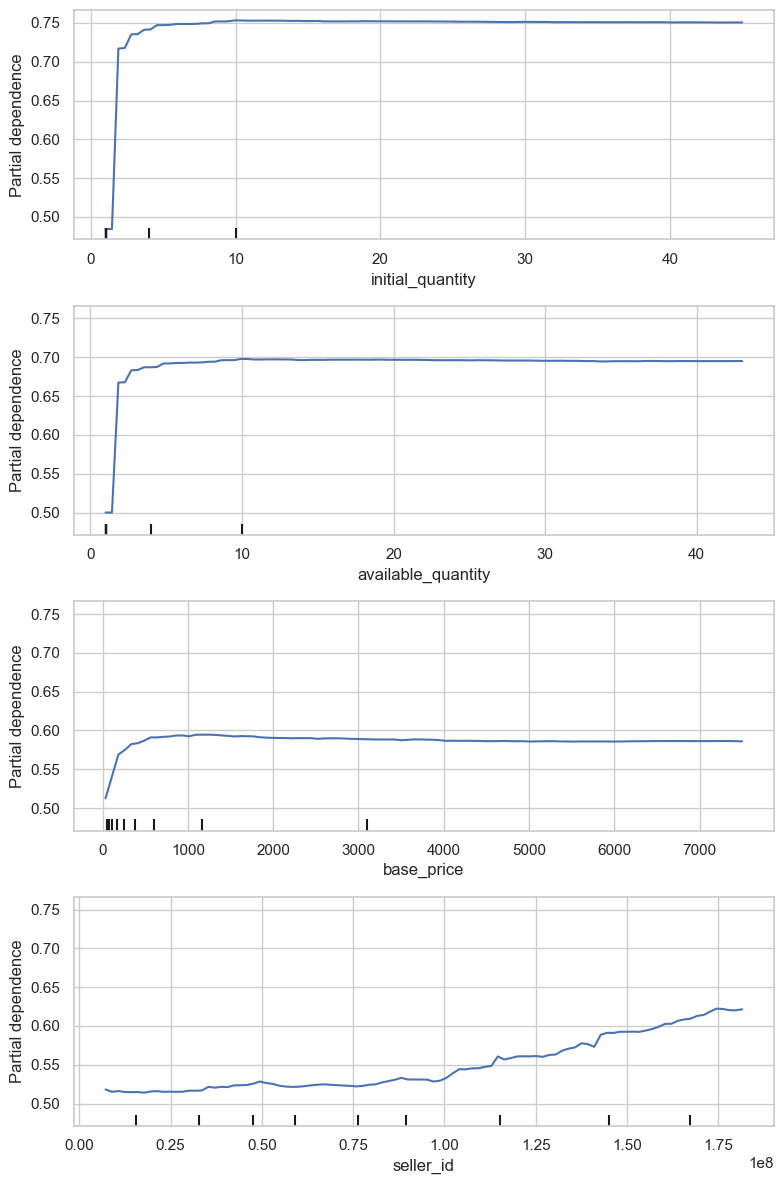

In [75]:

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

pdf = df_features.copy()
y = (pdf['condition'] == 'new').astype(int)
X = pdf.select_dtypes(include=['number']).fillna(0)
if X.shape[1] >= 2:
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X, y)
    top_feats = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(4).index.tolist()
    fig, ax = plt.subplots(len(top_feats), 1, figsize=(8, 3*len(top_feats)))
    PartialDependenceDisplay.from_estimator(rf, X, features=top_feats, ax=ax)
    plt.tight_layout()
else:
    print('Not enough numeric features for PDP.')


## Baseline-ready subsets (tabular and text)
Export engineered features for fast modeling experiments.

## JSONL Exports (original and engineered)
Write JSON Lines datasets for training/testing in separate notebooks.

In [80]:

import json
import pandas as pd
from pathlib import Path

out_dir = Path('processed')
out_dir.mkdir(exist_ok=True)

# 1) Original nested JSONL (with labels)
orig_path = out_dir / 'mla_original_with_labels.jsonlines'
with open('MLA_100k.jsonlines', 'r') as src, open(orig_path, 'w') as dst:
    for line in src:
        dst.write(line)

# 2) Original nested JSONL (without labels) — test-like
orig_nolabel_path = out_dir / 'mla_original_without_labels.jsonlines'
with open('MLA_100k.jsonlines', 'r') as src, open(orig_nolabel_path, 'w') as dst:
    for line in src:
        obj = json.loads(line)
        obj.pop('condition', None)
        dst.write(json.dumps(obj, ensure_ascii=False) + '\n')

# 3) Engineered feature table as JSONL
feat_path = out_dir / 'mla_items_features.jsonlines'
df_features.to_json(feat_path, orient='records', lines=True, force_ascii=False)

# 4) Baseline tabular subset as JSONL
try:
    X_tab = pd.read_parquet(out_dir / 'baseline_tabular.parquet')
except Exception:
    # Rebuild minimal X_tab if parquet not present
    y = df_features['condition'].map({'new':1, 'used':0}).astype('int8')
    keep = [c for c in df_features.columns if c in ['price','log_price','price_over_base','discount_rate','has_original_price','price_z_iqr','price_rank_pct_in_cat','sold_per_day','days_live','auto_relist','picture_count','attributes_count','variation_count','recency_days','price_resid_cat','category_id','listing_type_id']]
    X_tab = df_features[keep].copy()
    X_tab['condition'] = y

X_tab_jsonl = out_dir / 'baseline_tabular.jsonlines'
X_tab.to_json(X_tab_jsonl, orient='records', lines=True, force_ascii=False)

# 5) Baseline text subset as JSONL
try:
    text_df = pd.read_parquet(out_dir / 'baseline_text.parquet')
except Exception:
    text_df = pd.DataFrame({
        'title': df_features['title'].fillna(''),
        'description': (descriptions if 'descriptions' in globals() else pd.Series(['']*len(df_features))),
        'condition': df_features['condition'].map({'new':1, 'used':0}).astype('int8')
    })

text_jsonl = out_dir / 'baseline_text.jsonlines'
text_df.to_json(text_jsonl, orient='records', lines=True, force_ascii=False)

orig_path, orig_nolabel_path, feat_path, X_tab_jsonl, text_jsonl


(PosixPath('processed/mla_original_with_labels.jsonlines'),
 PosixPath('processed/mla_original_without_labels.jsonlines'),
 PosixPath('processed/mla_items_features.jsonlines'),
 PosixPath('processed/baseline_tabular.jsonlines'),
 PosixPath('processed/baseline_text.jsonlines'))